# **MAG**netic **PAR**ticle **SOL**ver

&nbsp;

`magparsol` is a compact Python library for the orbits of charged particles in prescribed electromagnetic fields, relativistic or not, together with tools to analyse and visualise them.

This notebook is its documentation. Every section introduces one piece of physics, runs it, and **checks the result against the analytic expectation**. A failed check stops the notebook.

&nbsp;

The particles obey the Lorentz force law

$$
\frac{d(\gamma m\mathbf v)}{dt} = q\left(\mathbf E + \mathbf v\times\mathbf B\right),\qquad \frac{d\mathbf r}{dt} = \mathbf v ,
$$

in SI units throughout. A field model returns $\mathbf B$ and $\mathbf E$ for a whole array of positions at once, so ensembles of $N$ particles advance together in one vectorised step.

### Package Structure

```
MASS/Plasma/
├── magparsol/
│   ├── __init__.py          public interface
│   ├── constants.py         CODATA 2018 constants, IGRF 14 dipole
│   ├── fields.py            field models
│   ├── particles.py         particle states and initial conditions
│   ├── integrators/
│   │   ├── base.py          shared time loop and history recording
│   │   ├── boris.py         Boris A, B, C
│   │   └── rungekutta.py    Dormand–Prince Runge–Kutta, fixed or adaptive
│   ├── diagnostics.py       trajectory history, gyration quantities, step checks
│   ├── plotting.py          trajectories, energy, speed, live plotting
│   ├── fieldlines.py        field line plots
│   ├── radiation.py         radiated power and spectra
│   ├── animation.py         overview figure and animations
│   └── style.py             shared colours and legend style
├── project/plots/           saved figures and animations
└── magparsol.ipynb          this notebook
```

&nbsp;

### Contents

1. Setup
2. Field Models
3. Gyration in a Uniform Field
4. Magnetic Mirror
5. $\mathbf E\times\mathbf B$ Drift
6. Integrators
7. Cyclotron Resonance
8. Trapped Particles in the Earth's Dipole
9. Radiation
10. Ensembles and Thermal Spectra
11. Overview and Animations
12. Live Plotting
13. Summary

## 1. Setup

&nbsp;

Figures are rendered as vector graphics. Very dense curves, such as long orbits, are embedded as high resolution raster images inside the vector figure to keep the notebook light. The package style restricts the palette to black, greys, steelblue, firebrick, olivedrab, goldenrod and rebeccapurple.

The helper `check` prints a measured value next to its theoretical value and asserts that both agree within a relative tolerance.

In [1]:
%matplotlib inline
%config InlineBackend.figure_formats = ["svg"]
from pathlib import Path

import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt

import magparsol
from magparsol import *

style.use()
PLOTS = Path("project/plots")
PLOTS.mkdir(parents=True, exist_ok=True)
print(f"magparsol {magparsol.__version__}   numpy {np.__version__}   matplotlib {mpl.__version__}")


def check(name, measured, expected, rtol):
    """Compare a measured value with theory and assert agreement within rtol."""
    err = abs(measured - expected) / abs(expected)
    print(f"  {name:<34s} {measured: .5g}   theory {expected: .5g}   relative error {err:.1e}")
    assert err < rtol, f"{name}: relative error {err:.2e} exceeds {rtol:g}"

magparsol 0.4.0   numpy 2.4.6   matplotlib 3.11.2


## 2. Field Models

&nbsp;

| Model | Field | Notes |
|:--|:--|:--|
| Uniform $\mathbf B$ | constant $\mathbf B$, no $\mathbf E$ | |
| Crossed fields | constant $\mathbf B$ and $\mathbf E$ | |
| Cyclotron wave | constant $\mathbf B$ plus $E_y = E_0\sin\omega_c t$ | wave frequency fixed to $\omega_c = \lvert q\rvert B/m$ |
| Earth dipole | tilted magnetic dipole | IGRF 14 tilt and moment for 2025 |
| Custom field | any user function | scalar form $(x, y, z, t)$ or vector form $(\mathbf r, t)$ |

&nbsp;

The field line plotter picks a representation that suits the field:

* **Uniform fields** are drawn as arrow grids. A component normal to the page is marked ⊙ when it points out of the page and ⊗ when it points into it.
* **Dipole lines** are traced from the magnetic equator at fixed $L$ down to the Earth's surface. In a meridian plane they are the closed curves $r = L\cos^2\lambda$. Both the rotation axis and the tilted magnetic axis are drawn.
* **Other fields** are traced from seed points or drawn as streamlines.

&nbsp;

The custom example is a paraxial **magnetic bottle**

$$
\mathbf B = B_0\left(-\frac{xz}{L^2},\; -\frac{yz}{L^2},\; 1 + \frac{z^2}{L^2}\right),\qquad \nabla\cdot\mathbf B = 0 ,
$$

written once in the scalar form and once in the vector form; both must agree. The first two panels below test both orientations of a field normal to the page.

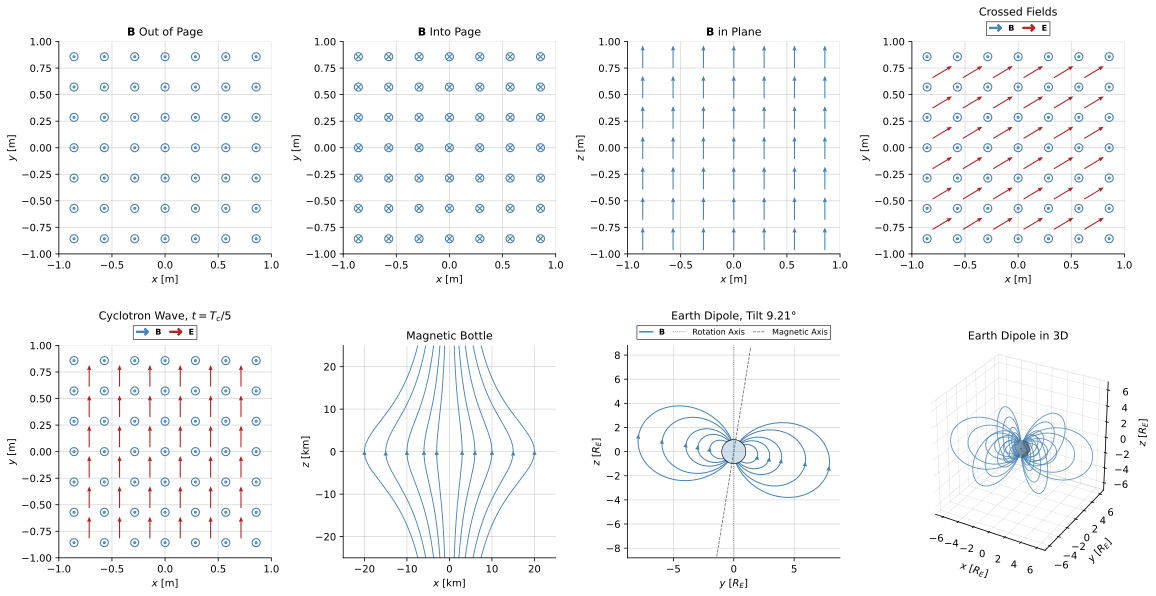

Equatorial surface field: 29.64 µT
  pole to equator field ratio         2   theory  2   relative error 2.2e-16
  field ratio at 2 and 1 Earth radii  0.125   theory  0.125   relative error 0.0e+00


In [2]:
def bottle(x, y, z, t, B0=1e-5, L=1e4):
    """Paraxial magnetic bottle in the scalar form."""
    k, zero = 1.0 / L**2, np.zeros_like(x)
    return -B0*k*x*z, -B0*k*y*z, B0*(1 + k*z**2), zero, zero, zero

def bottle_vec(r, t):
    """The same field in the vector form: positions (N, 3) to B, E (N, 3)."""
    c = bottle(r[:, 0], r[:, 1], r[:, 2], t)
    return np.column_stack(c[:3]), np.column_stack(c[3:])

bottle_field = CustomField(bottle, name="Magnetic Bottle")
r_test = np.random.default_rng(0).normal(scale=1e4, size=(10, 3))
assert np.allclose(bottle_field(r_test, 0)[0], CustomField(bottle_vec, vector_api=True)(r_test, 0)[0])
bottle_seeds = [[x*1e3, 0, 0] for x in (-20, -15, -10, -6, -3, 3, 6, 10, 15, 20)]

dip = EarthDipole()
cw = CyclotronWaveField(B=(0, 0, 1e-5), E_amp=1e-3)

fig = plt.figure(figsize=(16, 8.6))
ax = [fig.add_subplot(2, 4, i + 1) for i in range(7)] + [fig.add_subplot(2, 4, 8, projection="3d")]
plot_field_lines(UniformB(B=(0, 0, 1e-5)), projection="xy", ax=ax[0], title=r"$\mathbf{B}$ Out of Page")
plot_field_lines(UniformB(B=(0, 0, -1e-5)), projection="xy", ax=ax[1], title=r"$\mathbf{B}$ Into Page")
plot_field_lines(UniformB(B=(0, 0, 1e-5)), projection="xz", ax=ax[2], title=r"$\mathbf{B}$ in Plane")
plot_field_lines(UniformEB(B=(0, 0, 1e-5), E=(0.5, 0.3, 0)), components=("B", "E"),
                 projection="xy", ax=ax[3], title="Crossed Fields")
plot_field_lines(cw, components=("B", "E"), t=0.2 * 2*np.pi / cw.omega_c, projection="xy",
                 ax=ax[4], title=r"Cyclotron Wave, $t = T_c/5$")
plot_field_lines(bottle_field, projection="xz", length_unit=1e3, unit_label="km", ax_lim=25,
                 seed_points=bottle_seeds, ax=ax[5], title="Magnetic Bottle")
plot_field_lines(dip, projection="yz", length_unit=R_EARTH, unit_label=r"$R_E$", ax=ax[6],
                 title=f"Earth Dipole, Tilt {dip.tilt_deg:.2f}°")
plot_field_lines(dip, projection="3d", length_unit=R_EARTH, unit_label=r"$R_E$", ax_lim=7,
                 ax=ax[7], title="Earth Dipole in 3D")
fig.tight_layout(); plt.show()

B_eq = np.linalg.norm(dip(np.array([R_EARTH, 0, 0]), 0)[0])
B_pole = np.linalg.norm(dip(R_EARTH * dip.axis, 0)[0])
print(f"Equatorial surface field: {B_eq*1e6:.2f} µT")
check("pole to equator field ratio", B_pole / B_eq, 2.0, 1e-12)
check("field ratio at 2 and 1 Earth radii", dip.B_equator(2*R_EARTH) / B_eq, 1/8, 1e-12)

## 3. Gyration in a Uniform Field

&nbsp;

In a uniform $\mathbf B$ a particle circles a field line and moves freely along it: the orbit is a helix with

$$
\omega_c = \frac{\lvert q\rvert B}{\gamma m},\qquad T_c = \frac{2\pi}{\omega_c},\qquad r_L = \frac{\gamma m v_\perp}{\lvert q\rvert B}.
$$

The sense of rotation follows the sign of the charge. Seen from the tip of $\mathbf B$, ions gyrate **clockwise** and electrons **anticlockwise**, so in both cases the current loop weakens the field inside it: a plasma is diamagnetic.

&nbsp;

Below, a proton and an electron with the same speed gyrate for five periods. The time step comes from the package's step suggestion (200 steps per gyration) and is checked against the gyroperiod. The first plot shows the accumulated gyration phase, whose slope has opposite signs for the two charges. The second shows the proton helix in two projections.

proton: gyroperiod 6.559e-03 s, gyroradius 1.044e+02 m, dt/Tc 0.005
  proton gyroradius [m]               104.39   theory  104.4   relative error 8.2e-05
  proton gyrofrequency [rad/s]        957.88   theory  957.88   relative error 5.8e-08
electron: gyroperiod 3.572e-06 s, gyroradius 5.686e-02 m, dt/Tc 0.005


  electron gyroradius [m]             0.056852   theory  0.056856   relative error 8.2e-05
  electron gyrofrequency [rad/s]      1.7588e+06   theory  1.7588e+06   relative error 5.8e-08


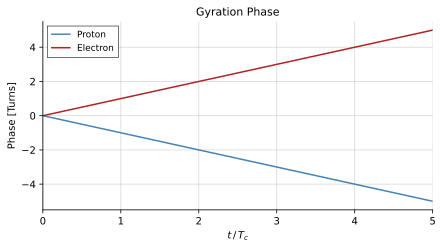

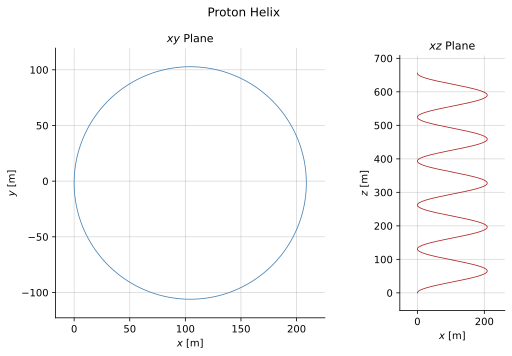

In [3]:
B0 = 1e-5
fB = UniformB(B=(0, 0, B0))
v_perp, v_par = 1e5, 2e4

fig, ax = plt.subplots(figsize=(7, 3.4))
for q, m, name, col in [(Q_E, M_P, "proton", "steelblue"), (-Q_E, M_E, "electron", "firebrick")]:
    Tc, rL = gyroperiod(q, m, B0), gyroradius(m, v_perp, q, B0)
    dt = suggest_dt(q, m, B0, steps_per_gyration=200)
    print(f"{name}: gyroperiod {Tc:.3e} s, gyroradius {rL:.3e} m, dt/Tc {check_dt_resolution(dt, q, m, B0):.3f}")

    sim = BorisC(single_particle(q=q, m=m, v0=[0, v_perp, v_par]), fB, dt=dt, t_max=5*Tc, relativistic=False)
    h = sim.run()
    x = h.r[:, 0, 0]
    phase = np.unwrap(np.arctan2(h.v[:, 0, 1], h.v[:, 0, 0]))
    omega = np.polyfit(h.t, phase, 1)[0]
    check(f"{name} gyroradius [m]", 0.5 * (x.max() - x.min()), rL, 1e-3)
    check(f"{name} gyrofrequency [rad/s]", abs(omega), gyrofrequency(q, m, B0), 1e-4)
    assert np.sign(omega) == -np.sign(q)
    ax.plot(h.t / Tc, (phase - phase[0]) / (2*np.pi), color=col, label=name.title())
    if q > 0:
        h_proton = h

ax.set_xlabel(r"$t\,/\,T_c$"); ax.set_ylabel("Phase [Turns]")
ax.set_xlim(0, 5); ax.set_ylim(-5.5, 5.5)
ax.set_title("Gyration Phase"); style.legend(ax, loc="upper left"); plt.show()

plot_trajectory_2d(h_proton, title="Proton Helix"); plt.show()

## 4. Magnetic Mirror

&nbsp;

When $\mathbf B$ varies slowly on the scale of $r_L$ and $T_c$, the magnetic moment $\mu = p_\perp^2/(2mB)$ is an **adiabatic invariant**. With constant speed in a static magnetic field this means $\sin^2\alpha / B$ stays constant. The pitch angle $\alpha$ therefore grows as the particle moves into stronger field, until it reflects where $B_m = B_0/\sin^2\alpha_0$.

&nbsp;

For the bottle $B_z = B_0(1 + z^2/L^2)$ the mirror point is $z_m = L\cot\alpha_0$, and the parallel motion is exactly harmonic,

$$
v_\parallel^2 = v^2\cos^2\alpha_0 - v^2\sin^2\alpha_0\,\frac{z^2}{L^2},\qquad T_b = \frac{2\pi L}{v\sin\alpha_0}.
$$

&nbsp;

A proton with $\alpha_0 = 30°$ is followed for two full bounce periods. On the left its orbit is shown over the bottle's field lines, on the right its height compared with the harmonic solution.

  mirror point [km]                   17.319   theory  17.321   relative error 1.1e-04
  bounce period [s]                   1.2568   theory  1.2566   relative error 1.2e-04
  magnetic moment varies by 3.3e-04 (gyroradius over L is 5.2e-03)


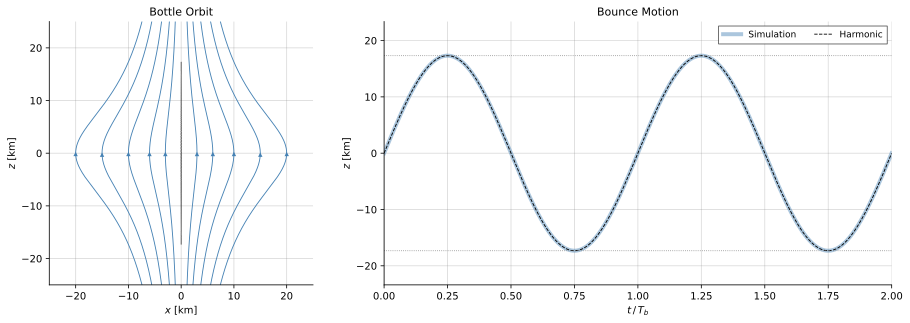

In [4]:
L_b, alpha0, v0 = 1e4, np.deg2rad(30), 1e5
Tc = gyroperiod(Q_E, M_P, 1e-5)
T_b = 2*np.pi*L_b / (v0*np.sin(alpha0))
p0 = single_particle(v0=[v0*np.sin(alpha0), 0, v0*np.cos(alpha0)])
h = BorisC(p0, bottle_field, dt=Tc/50, t_max=2*T_b, store_dt=Tc/10, relativistic=False).run()

z = h.r[:, 0, 2]
cross = np.where(np.sign(z[:-1]) * np.sign(z[1:]) < 0)[0]       # zero crossings, half a period apart
check("mirror point [km]", z.max() / 1e3, L_b / np.tan(alpha0) / 1e3, 2e-2)
check("bounce period [s]", 2 * np.diff(h.t[cross]).mean(), T_b, 2e-2)

B_loc = bottle_field(h.r[:, 0], 0)[0]
B_mag = np.linalg.norm(B_loc, axis=1)
mu = M_P * np.sum(np.cross(h.v[:, 0], B_loc / B_mag[:, None])**2, axis=1) / (2 * B_mag)
print(f"  magnetic moment varies by {np.ptp(mu) / mu.mean():.1e} (gyroradius over L is "
      f"{gyroradius(M_P, v0*np.sin(alpha0), Q_E, 1e-5)/L_b:.1e})")

fig, (a1, a2) = plt.subplots(1, 2, figsize=(13, 4.6), gridspec_kw={"width_ratios": [1, 1.7]})
plot_field_lines(bottle_field, history=h, projection="xz", length_unit=1e3, unit_label="km",
                 ax_lim=25, ax=a1, seed_points=bottle_seeds, orbit_alpha=0.8, title="Bottle Orbit")
z_m = L_b / np.tan(alpha0) / 1e3
a2.plot(h.t / T_b, z / 1e3, color="steelblue", lw=4, alpha=0.45, label="Simulation")
a2.plot(h.t / T_b, z_m * np.sin(2*np.pi * h.t / T_b), color="black", ls="--", lw=0.9, label="Harmonic")
for s in (1, -1):
    a2.axhline(s * z_m, color="grey", ls=":", lw=0.8)
a2.set_xlim(0, 2); a2.set_ylim(-1.35*z_m, 1.35*z_m)
a2.set_xlabel(r"$t\,/\,T_b$"); a2.set_ylabel("$z$ [km]"); a2.set_title("Bounce Motion")
style.legend(a2, loc="upper right", ncol=2)
fig.tight_layout(); plt.show()

## 5. $\mathbf E\times\mathbf B$ Drift

&nbsp;

A perpendicular electric field makes the guiding centre drift with

$$
\mathbf v_E = \frac{\mathbf E\times\mathbf B}{B^2},
$$

independent of charge, mass and velocity. To show this, eight protons and eight electrons start with random velocities. Their gyroradii differ by roughly the mass ratio $m_p/m_e \approx 1836$, yet each of them drifts with the same $\mathbf v_E$, here $5\times 10^4$ m/s in the $-y$ direction.

&nbsp;

The drift is measured as the displacement over four full gyrations. The Boris push is second order accurate, so the measured drift is expected to deviate from $\mathbf v_E$ by a few parts in $10^4$ at 100 steps per gyration.

  protons mean drift [m/s]           -49984   theory -50000   relative error 3.3e-04
  spread between particles 2.7e-07
  electrons mean drift [m/s]         -49984   theory -50000   relative error 3.3e-04
  spread between particles 2.8e-07


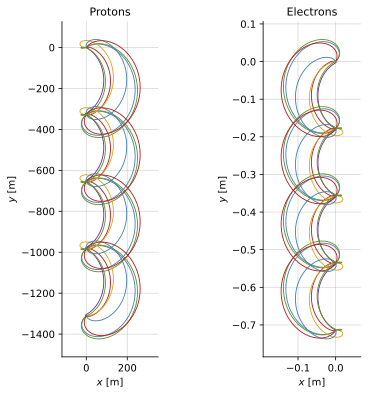

In [5]:
B0, E0 = 1e-5, np.array([0.5, 0.0, 0.0])
fEB = UniformEB(B=(0, 0, B0), E=E0)
vE = np.cross(E0, [0, 0, B0]) / B0**2

fig, axes = plt.subplots(1, 2, figsize=(6.4, 5.6))
for ax, (q, m, name) in zip(axes, [(Q_E, M_P, "Protons"), (-Q_E, M_E, "Electrons")]):
    Tc = gyroperiod(q, m, B0)
    ens = random_ensemble(8, q=q, m=m, v_max=1.5*abs(vE[1]), axes=(0, 1, 2), seed=4)
    h = BorisC(ens, fEB, dt=Tc/100, t_max=4*Tc, relativistic=False).run()
    v_drift = (h.r[-1] - h.r[0]) / (h.t[-1] - h.t[0])
    check(f"{name.lower()} mean drift [m/s]", v_drift[:, 1].mean(), vE[1], 1e-3)
    print(f"  spread between particles {np.ptp(v_drift[:, 1]) / abs(vE[1]):.1e}")
    for pid, col in zip(range(h.r.shape[1]), style.colors(8)):
        ax.plot(h.r[:, pid, 0], h.r[:, pid, 1], lw=0.9, color=col)
    ax.set_title(name); ax.set_xlabel("$x$ [m]"); ax.set_ylabel("$y$ [m]")
    pad = 0.06 * np.ptp(h.r[..., 1])
    ax.set_xlim(h.r[..., 0].min() - pad, h.r[..., 0].max() + pad)
    ax.set_ylim(h.r[..., 1].min() - pad, h.r[..., 1].max() + pad)
    ax.set_aspect("equal", adjustable="box")
fig.tight_layout(); plt.show()

## 6. Integrators

&nbsp;

| Integrator | Scheme | Order | Properties |
|:--|:--|:-:|:--|
| Boris A | Boris (1970) rotation, $\mathbf t = \tan(\theta/2)\,\hat{\mathbf b}$ | 2 | exact rotation angle $\theta = qB\Delta t/(\gamma m)$ |
| Boris B | textbook Boris, $\mathbf t = (\theta/2)\,\hat{\mathbf b}$ | 2 | rotates by $2\arctan(\theta/2) < \theta$: phase lag |
| Boris C | Zenitani & Umeda (2018), exact $\cos\theta$, $\sin\theta$ | 2 | exact phase, volume preserving |
| Runge–Kutta, nonrelativistic | Dormand–Prince on $\dot{\mathbf v} = (q/m)(\mathbf E + \mathbf v\times\mathbf B)$ | 5 | fixed or adaptive step |
| Runge–Kutta, relativistic | the same with $\gamma$ and the $\mathbf v\cdot\mathbf E$ term | 5 | fixed or adaptive step |

&nbsp;

All integrators share one run loop with a storage interval for the history, optional progress output and an optional live plotter.

&nbsp;

**Phase and energy.** The Boris rotation conserves $\lvert\mathbf u\rvert$ exactly, so a pure magnetic field never changes the energy, at any step size. The three Boris variants differ only in phase. For Boris B the phase error per step is $\theta - 2\arctan(\theta/2)$, which a deliberately coarse step $\Delta t = T_c/20$ at $v = 0.5c$ makes visible. Boris A and C stay exact, and their energy error is identically zero (plotted at the bottom edge). Runge–Kutta is of high order but not symplectic, so its energy error grows steadily.

Boris A      phase error after 50 periods -5.116e-13 rad, largest energy error 0.0e+00
Boris B      phase error after 50 periods +2.546e+00 rad, largest energy error 2.8e-15
  Boris B phase lag [rad]             2.5463   theory  2.5463   relative error 2.3e-13
Boris C      phase error after 50 periods -5.116e-13 rad, largest energy error 0.0e+00


Runge–Kutta  phase error after 50 periods -1.481e-02 rad, largest energy error 6.9e-04


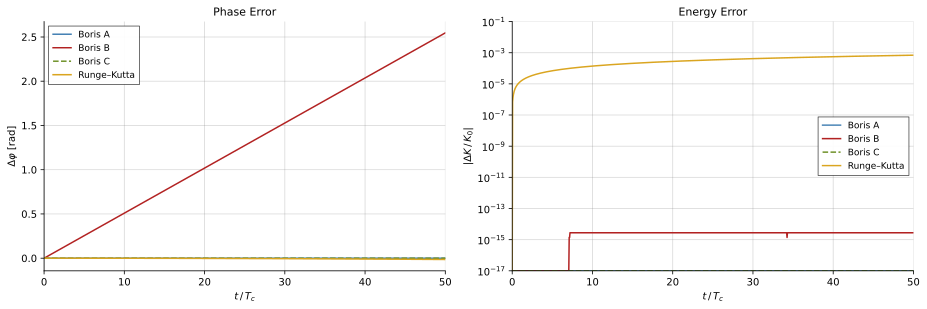

In [6]:
B0 = 1e-5
fB = UniformB(B=(0, 0, B0))
v0 = 0.5 * C
gamma0 = 1 / np.sqrt(1 - 0.5**2)
Tc = gamma0 * gyroperiod(Q_E, M_P, B0)
dt, theta = Tc/20, 2*np.pi/20

fig, (a1, a2) = plt.subplots(1, 2, figsize=(13, 4.4))
for cls, name, col in [(BorisA, "Boris A", "steelblue"), (BorisB, "Boris B", "firebrick"),
                       (BorisC, "Boris C", "olivedrab"), (RKrel, "Runge–Kutta", "goldenrod")]:
    sim = cls(single_particle(v0=[0, v0, 0]), fB, dt=dt, t_max=50*Tc, relativistic=True)
    h = sim.run()
    phase = np.unwrap(np.arctan2(h.v[:, 0, 1], h.v[:, 0, 0]))
    dphi = phase - phase[0] + 2*np.pi * h.t / Tc
    dE = np.abs(relative_energy_error(h, sim.state.m)[:, 0])
    a1.plot(h.t / Tc, dphi, color=col, label=name, ls="--" if name == "Boris C" else "-")
    a2.semilogy(h.t / Tc, np.maximum(dE, 1e-17), color=col, label=name,
                ls="--" if name == "Boris C" else "-")
    print(f"{name:12s} phase error after 50 periods {dphi[-1]:+.3e} rad, largest energy error {dE.max():.1e}")
    if name == "Boris B":
        check("Boris B phase lag [rad]", dphi[-1], (len(h.t) - 1) * (theta - 2*np.arctan(theta/2)), 1e-3)
    elif name in ("Boris A", "Boris C"):
        assert abs(dphi[-1]) < 1e-8 and dE.max() < 1e-12

a1.set_xlim(0, 50); a1.set_xlabel(r"$t\,/\,T_c$"); a1.set_ylabel(r"$\Delta\varphi$ [rad]")
a1.set_title("Phase Error"); style.legend(a1, loc="upper left")
a2.set_xlim(0, 50); a2.set_ylim(1e-17, 1e-1)
a2.set_xlabel(r"$t\,/\,T_c$"); a2.set_ylabel(r"$|\Delta K\,/\,K_0|$")
a2.set_title("Energy Error"); style.legend(a2, loc="center right")
fig.tight_layout(); plt.show()

&nbsp;

**Relativistic versus nonrelativistic.** At $v = 0.5c$ the nonrelativistic equation of motion overestimates the gyrofrequency by $\gamma = 1.155$ and underestimates the gyroradius by the same factor. Only the relativistic integrator reproduces $r_L = \gamma m v/(qB)$. Each orbit below is integrated for exactly one of its own gyroperiods.

  nonrelativistic radius [km]         156.49   theory  156.49   relative error 1.3e-11
  relativistic radius [km]            180.7   theory  180.7   relative error 1.2e-11


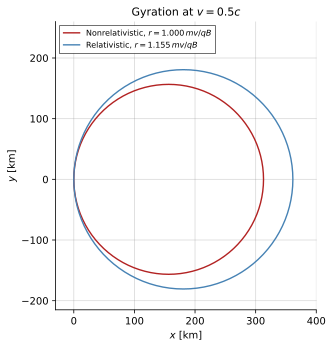

In [7]:
fig, ax = plt.subplots(figsize=(5.4, 5.2))
for cls, g, name, col in [(RKnonrel, 1.0, "Nonrelativistic", "firebrick"), (RKrel, gamma0, "Relativistic", "steelblue")]:
    T_own = g * gyroperiod(Q_E, M_P, B0)
    h = cls(single_particle(v0=[0, v0, 0]), fB, dt=T_own/200, t_max=T_own, relativistic=(g > 1)).run()
    x, y = h.r[:, 0, 0], h.r[:, 0, 1]
    check(f"{name.lower()} radius [km]", 0.5*(x.max() - x.min())/1e3, g * gyroradius(M_P, v0, Q_E, B0)/1e3, 1e-4)
    ax.plot(x / 1e3, y / 1e3, color=col, lw=1.4, label=rf"{name}, $r = {g:.3f}\,mv/qB$")
ax.set_aspect("equal"); ax.set_xlim(-30, 400); ax.set_ylim(-215, 260)
ax.set_xlabel("$x$ [km]"); ax.set_ylabel("$y$ [km]")
ax.set_title(r"Gyration at $v = 0.5c$"); style.legend(ax, loc="upper left", fontsize=8); plt.show()

## 7. Cyclotron Resonance

&nbsp;

The cyclotron wave adds an electric field $E_y = E_0\sin\omega_c t$ that oscillates exactly at the gyrofrequency. A linearly polarised wave is the sum of two circularly polarised ones of amplitude $E_0/2$. The one that corotates with the particle pushes it in phase on every turn, so for a particle starting at rest

$$
v_\perp(t) \simeq \frac{qE_0}{2m}\,t,\qquad K(t) \simeq \frac{(qE_0 t)^2}{8m}.
$$

&nbsp;

Off resonance the push drifts out of phase and the energy merely beats, bounded by a small value; the logarithmic energy axis shows both cases at once. That case uses a custom field written in the vector form, a uniform but time dependent wave detuned by 10 %.

  perpendicular acceleration [m/s²]   47873   theory  47894   relative error 4.5e-04


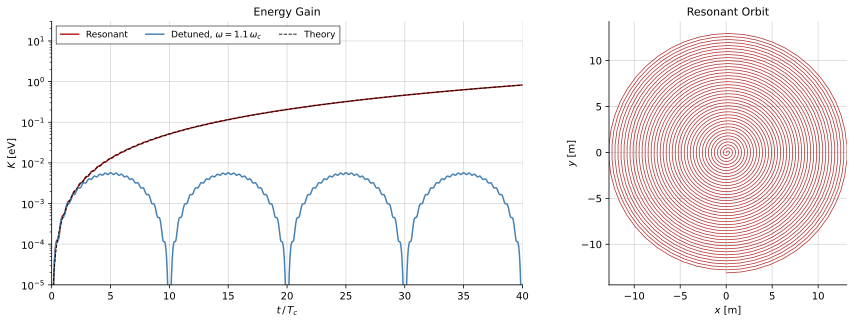

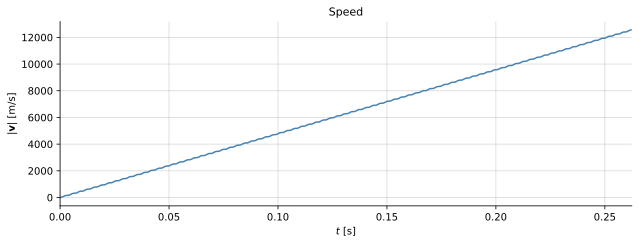

In [8]:
B0, E0 = 1e-5, 1e-3
cw = CyclotronWaveField(B=(0, 0, B0), q=Q_E, m=M_P, E_amp=E0)
Tc = 2*np.pi / cw.omega_c

def detuned_wave(r, t, w=1.1*cw.omega_c):
    B = np.tile([0.0, 0.0, B0], (len(r), 1))
    E = np.zeros_like(B); E[:, 1] = E0 * np.sin(w * t)
    return B, E
off = CustomField(detuned_wave, vector_api=True, is_uniform=True, is_static=False, name="Detuned Wave")

runs = {}
for name, field in [("Resonant", cw), (r"Detuned, $\omega = 1.1\,\omega_c$", off)]:
    runs[name] = BorisC(single_particle(), field, dt=Tc/100, t_max=40*Tc, store_dt=Tc/50,
                        relativistic=False).run()

h = runs["Resonant"]
v_perp = np.hypot(h.v[:, 0, 0], h.v[:, 0, 1])
late = h.t > 5*Tc
check("perpendicular acceleration [m/s²]", np.polyfit(h.t[late], v_perp[late], 1)[0], Q_E*E0/(2*M_P), 1e-2)

fig, (a1, a2) = plt.subplots(1, 2, figsize=(12.5, 4.6), gridspec_kw={"width_ratios": [1.5, 1]})
for (name, hh), col in zip(runs.items(), ["firebrick", "steelblue"]):
    K = hh.kinetic_energy(np.array([M_P]), relativistic=False)[:, 0] / Q_E
    a1.plot(hh.t / Tc, K, color=col, label=name)
a1.plot(h.t / Tc, (Q_E*E0*h.t)**2 / (8*M_P) / Q_E, color="black", ls="--", lw=0.9, label="Theory")
a1.set_yscale("log"); a1.set_xlim(0, 40); a1.set_ylim(1e-5, 30)
a1.set_xlabel(r"$t\,/\,T_c$"); a1.set_ylabel("$K$ [eV]"); a1.set_title("Energy Gain")
style.legend(a1, loc="upper left", ncol=3)
a2.plot(h.r[:, 0, 0], h.r[:, 0, 1], color="firebrick", lw=0.7)
a2.set_aspect("equal"); a2.set_xlabel("$x$ [m]"); a2.set_ylabel("$y$ [m]"); a2.set_title("Resonant Orbit")
fig.tight_layout(); plt.show()

plot_speed(h, relativistic=False, title="Speed"); plt.show()

## 8. Trapped Particles in the Earth's Dipole

&nbsp;

Radiation belt particles combine three periodic motions on well separated timescales.

&nbsp;

**Gyration** about the field line, with period $T_c$.

&nbsp;

**Bounce** between the mirror latitudes $\pm\lambda_m$, where $\cos^6\lambda_m = \sin^2\alpha_{eq}\sqrt{1+3\sin^2\lambda_m}$. Integrating $ds/v_\parallel$ along the dipole line $r = LR_E\cos^2\lambda$ gives

$$
\tau_b = \frac{4LR_E}{v}\int_0^{\lambda_m}\frac{\cos\lambda\,\sqrt{1+3\sin^2\lambda}}{\sqrt{1-\sin^2\alpha_{eq}\,B(\lambda)/B_{eq}}}\,d\lambda \;\approx\; \frac{4LR_E}{v}\,(1.30 - 0.56\sin\alpha_{eq}).
$$

&nbsp;

**Drift** around the Earth, caused by the field gradient and curvature: westward for protons, eastward for electrons, at

$$
\omega_d \approx \frac{3L\gamma m v^2}{q B_E R_E^2}\,(0.35 + 0.15\sin\alpha_{eq}),\qquad B_E R_E^2 = \frac{M}{R_E}.
$$

&nbsp;

The approximations are those of Hamlin et al. (1961), good to about 2 %. Guiding centre theory also neglects corrections of order $r_L/LR_E$, about 2 % for the particle below, so the drift is checked to 5 %; at lower energy the measured drift converges to the formula.

&nbsp;

The example is a 20 MeV proton at $L = 3$ with equatorial pitch angle $45°$, followed for one complete drift around the Earth. The dipole is tilted about $\hat{\mathbf x}$, so the starting point $3R_E\,\hat{\mathbf x}$ lies on the magnetic equator; latitude and azimuth are measured in the magnetic frame.

In [9]:
from scipy.integrate import quad
from scipy.optimize import brentq

L, W_MeV, alpha_eq = 3.0, 20.0, np.deg2rad(45)
gamma = 1 + W_MeV*1e6*Q_E / (M_P*C**2)
v = C * np.sqrt(1 - 1/gamma**2)

r0 = np.array([L*R_EARTH, 0.0, 0.0])
b_hat = dip(r0, 0)[0][0]; b_hat /= np.linalg.norm(b_hat)
e_perp = np.cross(b_hat, [1.0, 0.0, 0.0]); e_perp /= np.linalg.norm(e_perp)
trapped = dipole_initial_conditions(r0=r0, v0=v * (np.sin(alpha_eq)*e_perp + np.cos(alpha_eq)*b_hat))

B_eq = dip.B_equator(L*R_EARTH)
Tc = 2*np.pi*gamma*M_P / (Q_E*B_eq)
s2 = np.sin(alpha_eq)**2
B_rel = lambda lam: np.sqrt(1 + 3*np.sin(lam)**2) / np.cos(lam)**6
lam_m = brentq(lambda lam: 1 - s2*B_rel(lam), 0, np.pi/2 - 1e-6)
tau_b = 4*L*R_EARTH/v * quad(lambda lam: np.cos(lam)*np.sqrt(1 + 3*np.sin(lam)**2)
                             / np.sqrt(max(1 - s2*B_rel(lam), 1e-300)), 0, lam_m, limit=200)[0]
w_d = 3*L*gamma*M_P*v**2*R_EARTH / (Q_E*DIPOLE_MOMENT) * (0.35 + 0.15*np.sin(alpha_eq))
tau_d = 2*np.pi / w_d
print(f"gamma {gamma:.4f}, speed {v/C:.3f} c, equatorial field {B_eq*1e9:.0f} nT, "
      f"gyroradius {gyroradius(gamma*M_P, v*np.sin(alpha_eq), Q_E, B_eq)/R_EARTH:.3f} Earth radii")
print(f"mirror latitude {np.degrees(lam_m):.1f}°, gyration {Tc*1e3:.1f} ms, bounce {tau_b:.3f} s, drift {tau_d:.1f} s")

sim = BorisC(trapped.copy(), dip, dt=Tc/40, t_max=1.05*tau_d, store_dt=Tc/8)
h_dip = sim.run()
r, n_gyr = h_dip.r[:, 0], 8

def smooth(a):
    """Average over one gyration, an estimate of the guiding centre."""
    return np.convolve(a, np.ones(n_gyr)/n_gyr, mode="same")

e_b = np.cross(dip.axis, [1.0, 0.0, 0.0])
lat = smooth(r @ dip.axis) / R_EARTH
phi = np.unwrap(np.arctan2(r @ e_b, r[:, 0]))
up = np.where((lat[:-1] < 0) & (lat[1:] >= 0))[0][1:-1]
dE = relative_energy_error(h_dip, sim.state.m)[:, 0]

check("bounce period [s]", np.diff(h_dip.t[up]).mean(), tau_b, 1e-2)
check("drift rate [rad/s]", abs(np.polyfit(h_dip.t, phi, 1)[0]), w_d, 5e-2)
assert np.polyfit(h_dip.t, phi, 1)[0] < 0
assert np.abs(dE).max() < 1e-10
print(f"  largest energy error {np.abs(dE).max():.1e}")

B_loc = dip(r, 0)[0]; Bm = np.linalg.norm(B_loc, axis=1)
p_perp2 = (gamma*M_P)**2 * np.sum(np.cross(h_dip.v[:, 0], B_loc/Bm[:, None])**2, axis=1)
mu = smooth(p_perp2 / (2*gamma*M_P*Bm))[n_gyr:-n_gyr]
print(f"  magnetic moment, averaged over a gyration, varies by {np.ptp(mu)/mu.mean():.1%}")

gamma 1.0213, speed 0.203 c, equatorial field 1098 nT, gyroradius 0.066 Earth radii
mirror latitude 23.1°, gyration 61.0 ms, bounce 1.114 s, drift 46.6 s


  bounce period [s]                   1.1103   theory  1.114   relative error 3.3e-03
  drift rate [rad/s]                  0.13966   theory  0.13476   relative error 3.6e-02
  largest energy error 1.0e-14
  magnetic moment, averaged over a gyration, varies by 4.7%


&nbsp;

The 3D view shows the complete drift shell. Below it: the meridional projection over the dipole field lines, the bounce motion over the first four bounce periods, the steady westward drift compared with the Hamlin rate, and the magnetic moment averaged over each gyration.

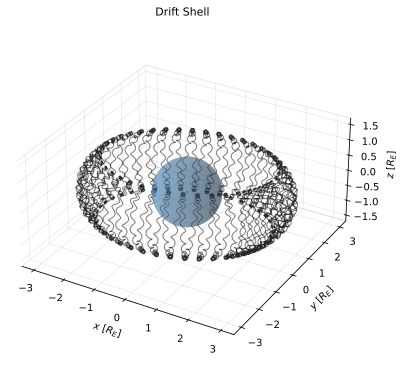

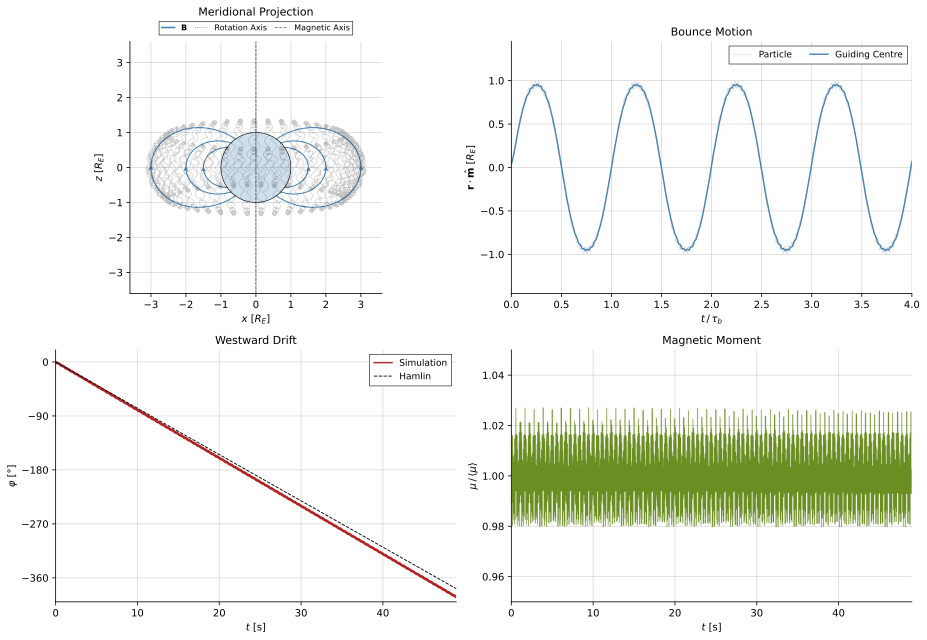

In [10]:
fig, ax3 = plot_trajectory_3d(h_dip, earth_sphere=True, ax_lim=3.4, z_ratio=0.5, color="black",
                              title="Drift Shell")
fig.set_size_inches(7.5, 5.2); plt.show()

fig, ax = plt.subplots(2, 2, figsize=(13, 9))
plot_field_lines(dip, history=h_dip, projection="xz", length_unit=R_EARTH, unit_label=r"$R_E$",
                 ax_lim=3.6, ax=ax[0, 0], L_shells=(1.5, 2, 3), orbit_alpha=0.25, title="Meridional Projection")
mask = h_dip.t < 4*tau_b
ax[0, 1].plot(h_dip.t[mask] / tau_b, (r @ dip.axis)[mask] / R_EARTH, color="lightgrey", lw=0.6, label="Particle")
ax[0, 1].plot(h_dip.t[mask] / tau_b, lat[mask], color="steelblue", lw=1.4, label="Guiding Centre")
ax[0, 1].set_xlim(0, 4); ax[0, 1].set_ylim(-1.45, 1.45)
ax[0, 1].set_xlabel(r"$t\,/\,\tau_b$"); ax[0, 1].set_ylabel(r"$\mathbf{r}\cdot\hat{\mathbf{m}}$ [$R_E$]")
ax[0, 1].set_title("Bounce Motion"); style.legend(ax[0, 1], loc="upper right", ncol=2)

ax[1, 0].plot(h_dip.t, np.degrees(phi), color="firebrick", lw=1.4, label="Simulation")
ax[1, 0].plot(h_dip.t, np.degrees(phi[0] - w_d*h_dip.t), color="black", ls="--", lw=0.9, label="Hamlin")
ax[1, 0].set_xlim(0, h_dip.t[-1]); ax[1, 0].set_ylim(-400, 20); ax[1, 0].set_yticks(np.arange(-360, 1, 90))
ax[1, 0].set_xlabel("$t$ [s]"); ax[1, 0].set_ylabel(r"$\varphi$ [°]")
ax[1, 0].set_title("Westward Drift"); style.legend(ax[1, 0], loc="upper right")

ax[1, 1].plot(h_dip.t[n_gyr:-n_gyr], mu / mu.mean(), color="olivedrab", lw=0.6, rasterized=True)
ax[1, 1].set_xlim(0, h_dip.t[-1]); ax[1, 1].set_ylim(0.95, 1.05)
ax[1, 1].set_xlabel("$t$ [s]"); ax[1, 1].set_ylabel(r"$\mu\,/\,\langle\mu\rangle$")
ax[1, 1].set_title("Magnetic Moment")
fig.tight_layout(); plt.show()

&nbsp;

**Adaptive step size.** The relativistic Runge–Kutta integrator can control its local error through a relative and an absolute tolerance. Along a bounce orbit the field, and with it the gyrofrequency, varies by a factor of two. The accepted step follows $\Delta t \propto 1/B$, while a fixed step scheme must use the smallest step everywhere. The thin curve shows every accepted step; the thick one is its average over a gyration.

2085 accepted steps; the step varies by a factor 3.60, the field by 1.98; correlation of step and inverse field 0.845
largest energy error 8.6e-06


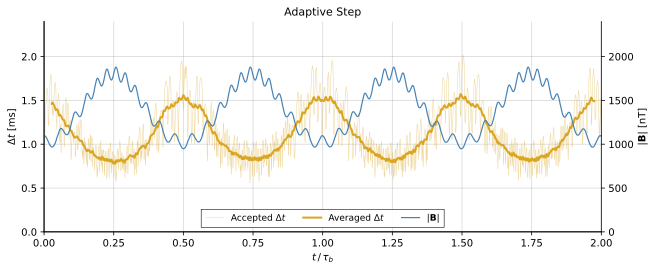

In [11]:
sim_rk = RKrel(trapped.copy(), dip, dt=Tc/40, t_max=2*tau_b, adaptive=True, rtol=1e-7, atol=1e-3)
h_rk = sim_rk.run()
dt_acc = np.diff(h_rk.t)
B_rk = np.linalg.norm(dip(h_rk.r[:-1, 0], 0)[0], axis=1)
print(f"{len(dt_acc)} accepted steps; the step varies by a factor {dt_acc.max()/dt_acc.min():.2f}, "
      f"the field by {B_rk.max()/B_rk.min():.2f}; correlation of step and inverse field {np.corrcoef(dt_acc, 1/B_rk)[0, 1]:.3f}")
print(f"largest energy error {np.abs(relative_energy_error(h_rk, sim_rk.state.m)).max():.1e}")

k = 40
fig, a1 = plt.subplots(figsize=(10, 3.8))
a1.plot(h_rk.t[1:] / tau_b, dt_acc * 1e3, color="goldenrod", lw=0.5, alpha=0.45, label=r"Accepted $\Delta t$")
a1.plot(h_rk.t[1:][k//2:-k//2] / tau_b, np.convolve(dt_acc, np.ones(k)/k, "same")[k//2:-k//2] * 1e3,
        color="goldenrod", lw=2, label=r"Averaged $\Delta t$")
a1.set_xlim(0, 2); a1.set_ylim(0, 2.4)
a1.set_xlabel(r"$t\,/\,\tau_b$"); a1.set_ylabel(r"$\Delta t$ [ms]")
a2 = a1.twinx(); a2.grid(False); a2.spines["right"].set_visible(True)
a2.plot(h_rk.t[1:] / tau_b, B_rk * 1e9, color="steelblue", lw=1.2, label=r"$|\mathbf{B}|$")
a2.set_ylim(0, 2400); a2.set_ylabel(r"$|\mathbf{B}|$ [nT]")
style.legend(a1, handles=a1.get_lines() + a2.get_lines(), loc="lower center", ncol=3)
a1.set_title("Adaptive Step"); plt.show()

## 9. Radiation

&nbsp;

**Power.** An accelerated charge radiates the Liénard power

$$
P = \frac{q^2\gamma^6}{6\pi\varepsilon_0 c^3}\left[\,a^2 - \frac{\lvert\mathbf v\times\mathbf a\rvert^2}{c^2}\right]
\;\longrightarrow\; \frac{q^2\gamma^4 a^2}{6\pi\varepsilon_0 c^3}\quad\text{for circular motion},\quad a = v\,\omega_c .
$$

The package evaluates this along the stored orbit, with the acceleration taken from the Lorentz force rather than from finite differences, and integrates it in time for the radiated energy.

In [12]:
B0 = 1e-5
fB = UniformB(B=(0, 0, B0))
for name, q, m, beta in [("proton at 0.01 c", Q_E, M_P, 0.01), ("electron at 0.9 c", -Q_E, M_E, 0.9)]:
    g = 1 / np.sqrt(1 - beta**2)
    w = abs(q) * B0 / (g * m)
    sim = BorisC(single_particle(q=q, m=m, v0=[0, beta*C, 0]), fB, dt=2*np.pi/w/400,
                 t_max=10 * 2*np.pi/w, store_dt=2*np.pi/w/100)
    h = sim.run()
    P = radiated_power(h, sim.state.q, sim.state.m, fB)[:, 0]
    P_th = q**2 * g**4 * (beta*C*w)**2 / (6*np.pi*EPS0*C**3)
    print(name)
    check("  radiated power [W]", P.mean(), P_th, 1e-6)
    check("  energy over 10 gyrations [J]", total_radiated_energy(h, sim.state.q, sim.state.m, fB)[0],
          P_th * h.t[-1], 1e-6)

proton at 0.01 c
    radiated power [W]                4.7078e-35   theory  4.7078e-35   relative error 2.6e-13
    energy over 10 gyrations [J]      3.0882e-36   theory  3.0882e-36   relative error 2.6e-13


electron at 0.9 c
    radiated power [W]                6.7659e-24   theory  6.7659e-24   relative error 2.1e-14
    energy over 10 gyrations [J]      5.5451e-28   theory  5.5451e-28   relative error 2.1e-14


&nbsp;

**Spectra.** The fast spectrum is the Fourier transform of the transverse acceleration seen by an observer in direction $\hat{\mathbf n}$. It is correct for slow particles: a single line at $f_c$ whose width shrinks as $1/T_{obs}$.

&nbsp;

The retarded spectrum evaluates Jackson's integral (Eq. 14.67)

$$
\frac{d^2I}{d\omega\,d\Omega} \propto \omega^2\left\lvert\int \hat{\mathbf n}\times(\hat{\mathbf n}\times\boldsymbol\beta)\, e^{\,i\omega(t - \hat{\mathbf n}\cdot\mathbf r/c)}\,dt\right\rvert^2 .
$$

The retardation phase turns relativistic gyration into **cyclotron and synchrotron harmonics** $n\,\omega_c$. Seen in the orbital plane they reach up to $\omega \sim \gamma^3\omega_c$ when $\beta \to 1$, and fall off roughly as $\beta^{2(n-1)}$ at low speed. A Hann window over the finite observation time suppresses spectral leakage.

  fast spectrum peak, f over fc       0.99917   theory  1   relative error 8.3e-04


beta 0.3: harmonic power relative to the fundamental (n = 2 to 5) 0.34, 0.083, 0.018, 0.0036
  beta 0.3: fundamental, omega over omega c  1.0014   theory  1   relative error 1.4e-03


beta 0.9: harmonic power relative to the fundamental (n = 2 to 5) 1.8, 2.5, 3, 3.4
  beta 0.9: fundamental, omega over omega c  1.0014   theory  1   relative error 1.4e-03


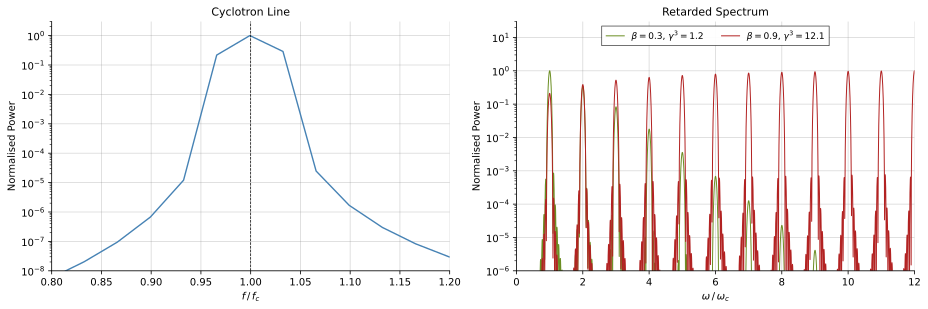

In [13]:
fig, (a1, a2) = plt.subplots(1, 2, figsize=(13, 4.4))

Tc = gyroperiod(Q_E, M_P, B0)
h = BorisC(single_particle(v0=[0, 1e5, 0]), fB, dt=Tc/200, t_max=30*Tc, store_dt=Tc/40).run()
f, p = spectrum_fft(h, store_dt_warn_period=Tc)
check("fast spectrum peak, f over fc", f[np.argmax(p)] * Tc, 1.0, 1/30)
a1.semilogy(f*Tc, p/p.max(), color="steelblue", lw=1.4)
a1.axvline(1, color="black", ls="--", lw=0.7)
a1.set_xlim(0.8, 1.2); a1.set_ylim(1e-8, 3)
a1.set_xlabel(r"$f\,/\,f_c$"); a1.set_ylabel("Normalised Power")
a1.set_title("Cyclotron Line")

n_hat = np.array([1.0, 0.0, 0.0])
for beta, col in [(0.3, "olivedrab"), (0.9, "firebrick")]:
    g = 1 / np.sqrt(1 - beta**2); w = Q_E*B0/(g*M_E); T = 2*np.pi/w
    h = BorisC(single_particle(q=-Q_E, m=M_E, v0=[0, beta*C, 0]), fB, dt=T/400,
               t_max=20*T, store_dt=T/200).run()
    omegas = np.linspace(0.05, 12, 2400) * w
    f, p = spectrum_retarded(h, omega_array=omegas, observer=n_hat)
    a2.semilogy(omegas/w, p/p.max(), color=col, lw=1, label=rf"$\beta = {beta}$, $\gamma^3 = {g**3:.1f}$")
    peaks = [p[np.abs(omegas/w - n) < 0.25].max() for n in range(1, 6)]
    print(f"beta {beta}: harmonic power relative to the fundamental (n = 2 to 5) " + ", ".join(f"{x/peaks[0]:.2g}" for x in peaks[1:]))
    check(f"beta {beta}: fundamental, omega over omega c", omegas[np.argmax(np.where(omegas/w < 1.5, p, 0))]/w, 1.0, 1e-2)
a2.set_xlim(0, 12); a2.set_ylim(1e-6, 30); a2.set_xticks(range(0, 13, 2))
a2.set_xlabel(r"$\omega\,/\,\omega_c$"); a2.set_ylabel("Normalised Power")
a2.set_title("Retarded Spectrum"); style.legend(a2, loc="upper center", ncol=2)
fig.tight_layout(); plt.show()

## 10. Ensembles and Thermal Spectra

&nbsp;

Three ensemble generators are available:

* **Random** velocities with uniformly distributed components (used in Section 5).
* **Maxwellian**, each component Gaussian with $\sigma = \sqrt{kT/m}$.
* **Maxwell–Jüttner**, the relativistic thermal distribution with $\theta = kT/mc^2$,

$$
f(\gamma) = \frac{\gamma^2\beta}{\theta\,K_2(1/\theta)}\,e^{-\gamma/\theta},\qquad \langle\gamma\rangle = 3\theta + \frac{K_1(1/\theta)}{K_2(1/\theta)} .
$$

&nbsp;

The ensemble spectrum adds the single particle spectra incoherently, the right sum for uncorrelated particles. A nonrelativistic thermal plasma radiates one sharp line, because $\omega_c$ does not depend on speed. In a relativistic plasma every particle radiates at $\omega_c/\gamma$, and the spread in $\gamma$ broadens the line into a continuum below $f_c$. Grey lines are individual particles, the coloured line their sum.

  Maxwell–Jüttner mean gamma          2.0555   theory  2.0512   relative error 2.1e-03
  Maxwellian velocity spread [m/s]    90446   theory  90854   relative error 4.5e-03


  Maxwellian protons peak, f over fc  0.99834   theory  1   relative error 1.7e-03


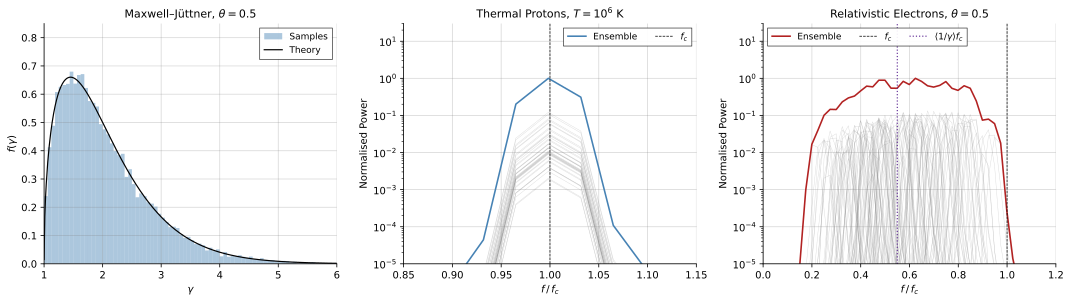

In [14]:
from scipy.special import kn

theta = 0.5
mj = relativistic_thermal_ensemble(20000, theta_e=theta, m=M_E, q=-Q_E, seed=1)
g_s = mj.gamma()
check("Maxwell–Jüttner mean gamma", g_s.mean(), 3*theta + kn(1, 1/theta)/kn(2, 1/theta), 1e-2)
mb = maxwellian_ensemble(20000, T=1e6, m=M_P, seed=1)
check("Maxwellian velocity spread [m/s]", mb.v.std(), np.sqrt(K_B*1e6/M_P), 1e-2)

Tp, Te = gyroperiod(Q_E, M_P, B0), gyroperiod(Q_E, M_E, B0)
h_mb = BorisC(maxwellian_ensemble(40, T=1e6, m=M_P, seed=2), fB, dt=Tp/100, t_max=30*Tp,
              store_dt=Tp/20, relativistic=False).run()
h_mj = BorisC(relativistic_thermal_ensemble(150, theta_e=theta, m=M_E, q=-Q_E, seed=2), fB,
              dt=Te/100, t_max=40*Te, store_dt=Te/20).run()
f_mb, P_mb, ind_mb = ensemble_spectrum(h_mb)
f_mj, P_mj, ind_mj = ensemble_spectrum(h_mj)
check("Maxwellian protons peak, f over fc", f_mb[np.argmax(P_mb)] * Tp, 1.0, 1/30)

fig, (a0, a1, a2) = plt.subplots(1, 3, figsize=(15, 4.3))
gg = np.linspace(1.0001, 6, 400)
a0.hist(g_s, bins=80, range=(1, 6), density=True, color="steelblue", alpha=0.45, label="Samples")
a0.plot(gg, gg**2*np.sqrt(1 - 1/gg**2)*np.exp(-gg/theta)/(theta*kn(2, 1/theta)), color="black", lw=1.2, label="Theory")
a0.set_xlim(1, 6); a0.set_ylim(0, 0.85)
a0.set_xlabel(r"$\gamma$"); a0.set_ylabel(r"$f(\gamma)$"); a0.set_title(rf"Maxwell–Jüttner, $\theta = {theta}$")
style.legend(a0, loc="upper right")
for ax, f, P, ind, T, ttl, xl, col in [
        (a1, f_mb, P_mb, ind_mb, Tp, r"Thermal Protons, $T = 10^6$ K", (0.85, 1.15), "steelblue"),
        (a2, f_mj, P_mj, ind_mj, Te, rf"Relativistic Electrons, $\theta = {theta}$", (0, 1.2), "firebrick")]:
    for p in ind:                                      # each particle's share of the total
        ax.semilogy(f*T, p/len(ind)/P.max(), color="grey", lw=0.4, alpha=0.3)
    ax.semilogy(f*T, P/P.max(), color=col, lw=1.6, label="Ensemble")
    ax.axvline(1, color="black", ls="--", lw=0.7, label=r"$f_c$")
    ax.set_xlim(*xl); ax.set_ylim(1e-5, 30)
    ax.set_xlabel(r"$f\,/\,f_c$"); ax.set_ylabel("Normalised Power"); ax.set_title(ttl)
a2.axvline((1/g_s).mean(), color="rebeccapurple", ls=":", lw=1.2, label=r"$\langle 1/\gamma\rangle f_c$")
style.legend(a1, loc="upper right", ncol=2); style.legend(a2, loc="upper left", ncol=3)
fig.tight_layout(); plt.show()

## 11. Overview and Animations

&nbsp;

The overview figure summarises a run in six panels: the position and the velocity in two projections each, the field configuration with the orbit, and the emission spectrum.

* Velocity panels highlight only the last few gyrations over the full hodograph in light grey.
* Over the field configuration the orbit is a trail of about one bounce period that fades towards its tail, so the field lines stay visible.
* The spectrum shows the final result in grey; in the animation the red curve is recomputed from the orbit observed so far. As the observation window grows the lines narrow and rise out of the window's side lobes.

&nbsp;

The example is the trapped proton of Section 8 over one complete drift around the Earth. Further animations show a single panel each: the trajectory, the rotating electric field of a resonant cyclotron wave, and the build up of a cyclotron line. All files are written to `project/plots`.

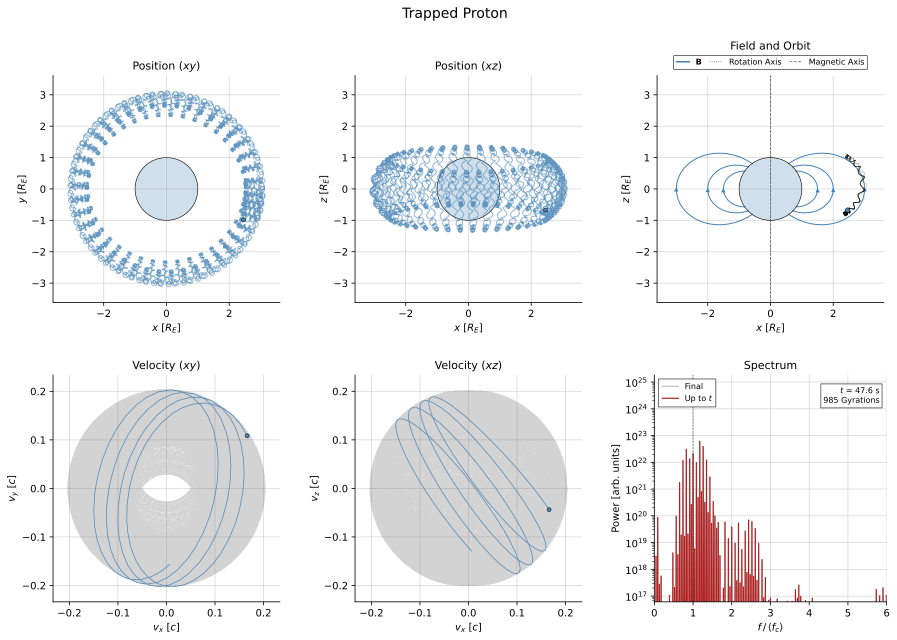

Saved: project/plots/overview.gif


Saved: project/plots/trajectory.gif


Saved: project/plots/cyclotron.gif


Saved: project/plots/spectrum.gif


In [15]:
sim = BorisC(trapped.copy(), dip, dt=Tc/40, t_max=1.02*tau_d, store_dt=Tc/6)
h_ov = sim.run()
n_bounce = int(round(tau_b / (Tc/6)))                  # stored samples per bounce period
kw = dict(q=sim.state.q, m=sim.state.m, length_unit=R_EARTH, unit_label=r"$R_E$",
          normalize_v=True, field_components=("B",), field_trail=n_bounce)

fig = plot_overview(h_ov, dip, title="Trapped Proton", **kw)
fig.savefig(PLOTS / "overview.pdf", bbox_inches="tight"); plt.show()

make_overview_gif(h_ov, dip, filename=PLOTS / "overview.gif", fps=12, n_frames=150, dpi=60,
                  title="Trapped Proton", **kw)
make_panel_gif(h_ov, "position_xy", field=dip, filename=PLOTS / "trajectory.gif", fps=15,
               n_frames=150, dpi=80, **kw)

cw = CyclotronWaveField(B=(0, 0, 1e-5), E_amp=1e-3)
T = 2*np.pi / cw.omega_c
sim = BorisC(single_particle(), cw, dt=T/100, t_max=6*T, store_dt=T/24, relativistic=False)
h_cw = sim.run()
make_panel_gif(h_cw, "field", field=cw, q=sim.state.q, m=sim.state.m, filename=PLOTS / "cyclotron.gif",
               fps=12, n_frames=len(h_cw.t), dpi=80)
h_sp = BorisC(single_particle(v0=[0, 1e5, 0]), UniformB(B=(0, 0, 1e-5)), dt=T/200, t_max=30*T,
              store_dt=T/40).run()
make_panel_gif(h_sp, "spectrum", field=UniformB(B=(0, 0, 1e-5)), q=sim.state.q, m=sim.state.m,
               filename=PLOTS / "spectrum.gif", fps=15, n_frames=120, dpi=80);

&nbsp;

| Overview |
|:-:|
| ![Overview](project/plots/overview.gif) |

| Trajectory | Resonant Wave | Spectrum |
|:-:|:-:|:-:|
| ![Trajectory](project/plots/trajectory.gif) | ![Cyclotron](project/plots/cyclotron.gif) | ![Spectrum](project/plots/spectrum.gif) |

## 12. Live Plotting

&nbsp;

A live plotter passed to the run loop redraws the $xy$ and $xz$ projections while the integration is still running: with output clearing in Jupyter, with short pauses in a script. It is meant for watching long runs; in a saved notebook only the final frame remains. Here it follows the trapped proton for one complete drift around the Earth.

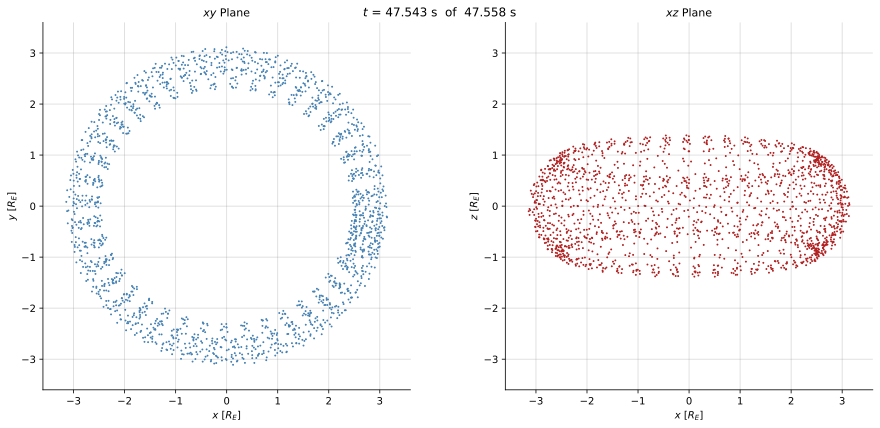

In [16]:
live = LivePlotter(ax_lim=3.6, length_unit=R_EARTH, unit_label=r"$R_E$")
sim = BorisC(trapped.copy(), dip, dt=Tc/40, t_max=1.02*tau_d, store_dt=Tc/10)
_ = sim.run(live_plotter=live, live_every=160)
live.close()

## 13. Summary

&nbsp;

| Section | Feature | Verified Against |
|:-:|:--|:--|
| 2 | all field models, field line plots, both custom field forms | pole to equator ratio 2, $B\propto r^{-3}$, scalar form equals vector form |
| 3 | gyration diagnostics, step suggestion and check, projections | $r_L$, $\omega_c$, sense of rotation |
| 4 | magnetic mirror in a custom field | $z_m = L\cot\alpha_0$, $T_b = 2\pi L/(v\sin\alpha_0)$, invariance of $\mu$ |
| 5 | crossed fields, random ensembles | $\mathbf v_E = \mathbf E\times\mathbf B/B^2$ for every particle |
| 6 | Boris A, B, C and Runge–Kutta integrators, energy error, speed | Boris B phase lag $\theta - 2\arctan(\theta/2)$, energy conservation, $r_L\propto\gamma$ |
| 7 | cyclotron wave, time dependent custom field | $\dot v_\perp = qE_0/2m$ on resonance |
| 8 | Earth dipole, 3D trajectories, adaptive Runge–Kutta | exact $\tau_b$, Hamlin $\omega_d$, westward drift, $\mu$, $\Delta t\propto 1/B$ |
| 9 | radiated power and energy, fast and retarded spectra | Liénard power, line at $f_c$, harmonics $n\omega_c$ |
| 10 | Maxwellian and Maxwell–Jüttner ensembles, ensemble spectra | $\langle\gamma\rangle$, $\sigma_v$, line versus continuum |
| 11 | overview figure and animations | visual |
| 12 | live plotting | visual |